In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import torch

In [2]:
base = Path("../attribution")

# Dreyer2023

In [3]:


def plot_temporal_saliency(dataset, model, window, subject=None, target=0, ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    files = os.listdir(base)
    files_to_load = []
    for file in files:
        if window in file and dataset in file and model in file:
            if subject is not None:
                if f"_{subject}.pt" in file:
                    files_to_load.append(file)
            else:
                files_to_load.append(file)

    saliency_list = []

    for file in files_to_load:
        data = torch.load(base / file, weights_only=False)
        saliency = data[target]["saliency"]

        saliency_list.append(saliency)

    saliency = np.mean(saliency_list, axis=0)

    saliency_temporal = saliency.mean(0)
    saliency_temporal = saliency_temporal / saliency_temporal.sum() * 100

    ax.plot(saliency_temporal)
    ax.set_xlabel("Time [samples]")
    ax.set_ylabel("Saliency in %")


def plot_spatial_saliency(dataset, model, window, subject=None, target=0, montage="standard_1020", ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    with open(f"../Dataset/{dataset}/meta_data.json", "r") as f:
        info = json.load(f)
    ch_names = info["ch_names"]

    files = os.listdir(base)
    files_to_load = []
    for file in files:
        if window in file and dataset in file and model in file:
            if subject is not None:
                if f"_{subject}.pt" in file:
                    files_to_load.append(file)
            else:
                files_to_load.append(file)

    saliency_list = []

    for file in files_to_load:
        data = torch.load(base / file, weights_only=False)
        saliency = data[target]["saliency"]

        saliency_list.append(saliency)

    saliency = np.mean(saliency_list, axis=0)

    saliency_spatial = saliency.mean(1)
    saliency_spatial = saliency_spatial / saliency_spatial.sum() * 100

    info = mne.create_info(ch_names, 1000.0, "eeg")
    info.set_montage(montage)
    #mne.viz.plot_topomap(saliency_spatial, info, axes=ax, show=False, extrapolate="local")

    montage = mne.channels.make_standard_montage(montage)
    ch_pos = montage.get_positions()["ch_pos"]
    ch_pos = np.array([ch_pos[ch_name][:2] for ch_name in ch_names])

    im, _ = mne.viz.plot_topomap(saliency_spatial, ch_pos, names=ch_names, cmap="Reds", axes=ax, show=False)

    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Saliency in %", rotation=270, labelpad=30)




Text(0.5, 0.98, 'Dreyer2023 (right_hand)')

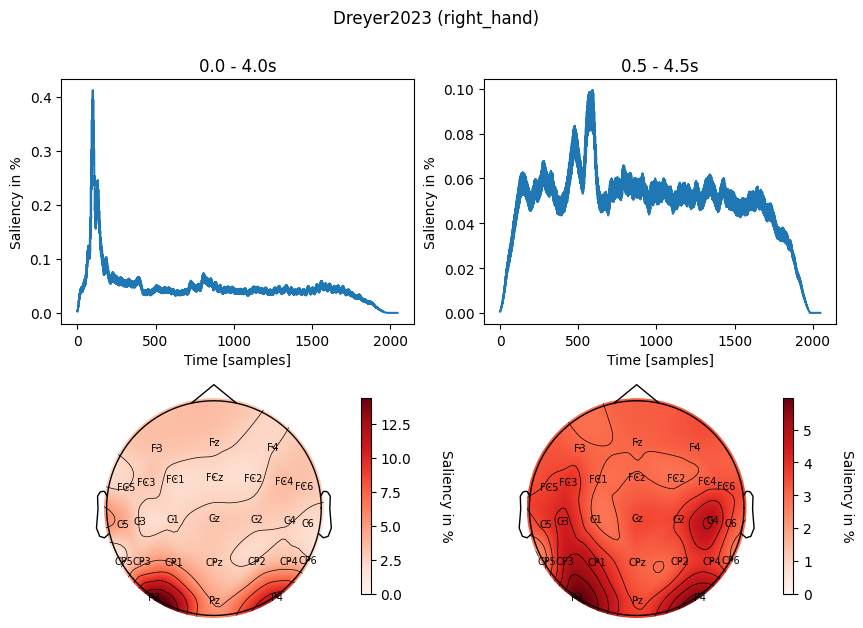

In [4]:

dataset = "Dreyer2023"
model = "Deep4Net"
windows = ["w_00_40", "w_05_45"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

plot_temporal_saliency(dataset, model, windows[0], subject=None, target=1, ax=axes[0, 0])
plot_temporal_saliency(dataset, model, windows[1], subject=None, target=1, ax=axes[0, 1])

plot_spatial_saliency(dataset, model, windows[0], subject=None, target=1, ax=axes[1, 0])
plot_spatial_saliency(dataset, model, windows[1], subject=None, target=1, ax=axes[1, 1])

axes[0, 0].set_title("0.0 - 4.0s")
axes[0, 1].set_title("0.5 - 4.5s")
fig.suptitle("Dreyer2023 (right_hand)")

Text(0.5, 0.98, 'Dreyer2023 (left_hand)')

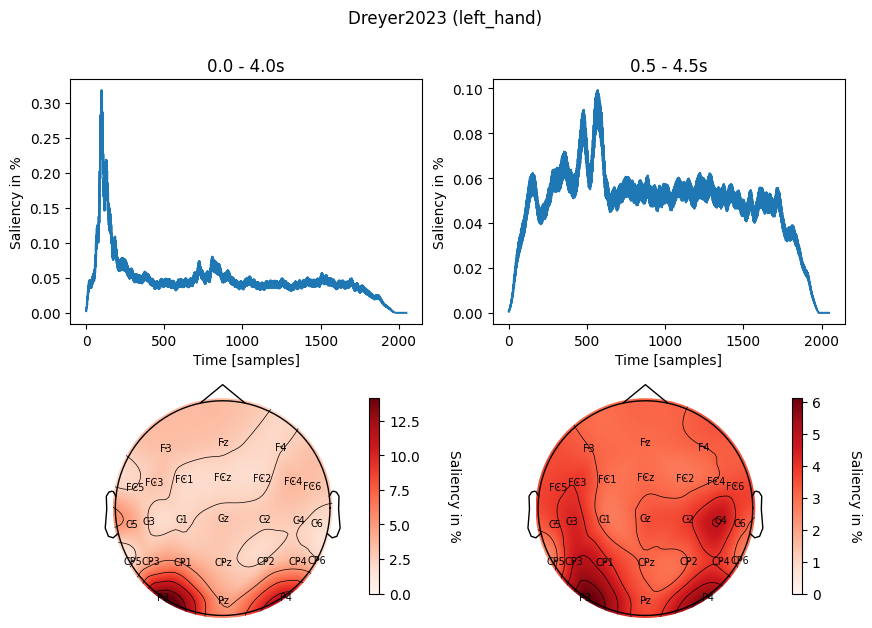

In [5]:
dataset = "Dreyer2023"
model = "Deep4Net"
windows = ["w_00_40", "w_05_45"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

plot_temporal_saliency(dataset, model, windows[0], subject=None, target=0, ax=axes[0, 0])
plot_temporal_saliency(dataset, model, windows[1], subject=None, target=0, ax=axes[0, 1])

plot_spatial_saliency(dataset, model, windows[0], subject=None, target=0, ax=axes[1, 0])
plot_spatial_saliency(dataset, model, windows[1], subject=None, target=0, ax=axes[1, 1])

axes[0, 0].set_title("0.0 - 4.0s")
axes[0, 1].set_title("0.5 - 4.5s")
fig.suptitle("Dreyer2023 (left_hand)")

#fig.savefig(Path.home() / "dreyer_left.png")

Text(0.5, 0.98, 'Lee2019 (right_hand)')

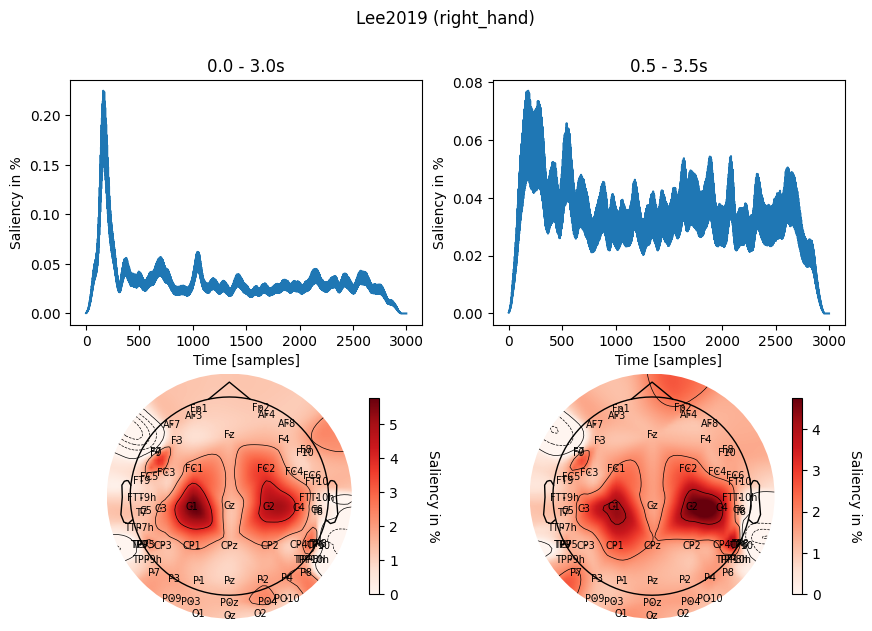

In [6]:
dataset = "Lee2019_MI"
model = "Deep4Net"
windows = ["w_00_30", "w_05_35"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

plot_temporal_saliency(dataset, model, windows[0], subject=None, target=1, ax=axes[0, 0])
plot_temporal_saliency(dataset, model, windows[1], subject=None, target=1, ax=axes[0, 1])

plot_spatial_saliency(dataset, model, windows[0], subject=None, target=1, ax=axes[1, 0], montage="standard_1005")
plot_spatial_saliency(dataset, model, windows[1], subject=None, target=1, ax=axes[1, 1], montage="standard_1005")

axes[0, 0].set_title("0.0 - 3.0s")
axes[0, 1].set_title("0.5 - 3.5s")
fig.suptitle("Lee2019 (right_hand)")


Text(0.5, 0.98, 'Lee2019 (left_hand)')

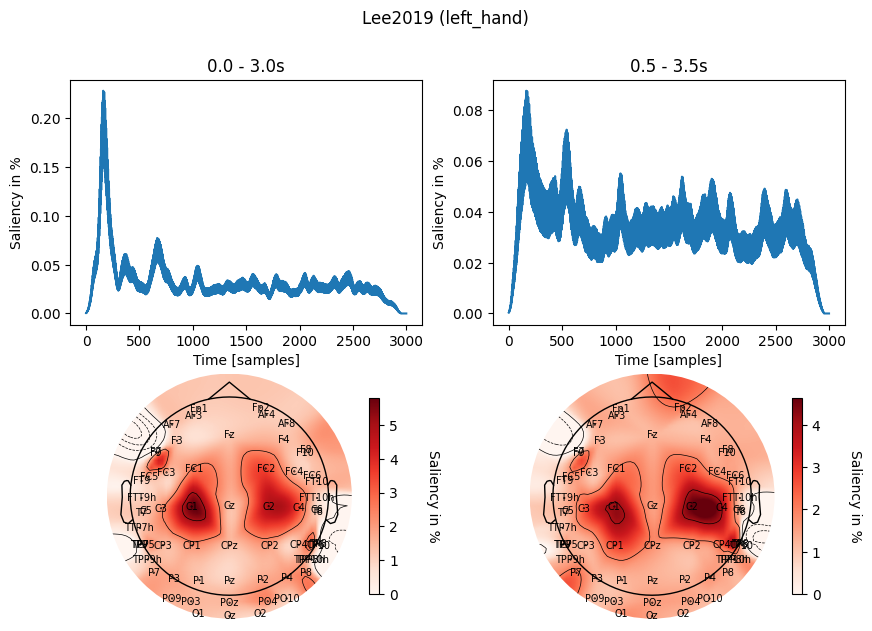

In [7]:

dataset = "Lee2019_MI"
model = "Deep4Net"
windows = ["w_00_30", "w_05_35"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

plot_temporal_saliency(dataset, model, windows[0], subject=None, target=0, ax=axes[0, 0])
plot_temporal_saliency(dataset, model, windows[1], subject=None, target=0, ax=axes[0, 1])

plot_spatial_saliency(dataset, model, windows[0], subject=None, target=0, ax=axes[1, 0], montage="standard_1005")
plot_spatial_saliency(dataset, model, windows[1], subject=None, target=0, ax=axes[1, 1], montage="standard_1005")

axes[0, 0].set_title("0.0 - 3.0s")
axes[0, 1].set_title("0.5 - 3.5s")
fig.suptitle("Lee2019 (left_hand)")
